In [ ]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn

# %pip install geopandas
# %pip install Point
# %pip install geodatasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("el_nino.csv")
df

,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
0,80,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24
1,80,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97
2,80,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28
3,80,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31
4,80,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19
...,...,...,...,...,...,...,...,...,...,...,...
178075,98,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14
178076,98,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87
178077,98,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93
178078,98,6,14,980614,8.96,-140.33,-4.9,-2.3,76.2,27.36,28.03


In [ ]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.sort_values(by='date')
df_cleaned.head(10)


,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
75636,89,11,29,891129,-2.04,-140.09,-7.2,-0.2,78.7,26.01,25.92
75637,89,11,30,891130,-2.03,-140.08,-6.1,0.2,76.9,25.82,25.98
75638,89,12,1,891201,-2.05,-140.08,-5.2,0.0,75.9,25.58,26.03
75639,89,12,2,891202,-2.04,-140.07,-3.7,-0.4,76.8,25.46,26.14
75640,89,12,3,891203,-2.04,-140.08,-4.6,-0.6,75.7,25.54,26.16
75641,89,12,4,891204,-2.04,-140.08,-5.4,-2.0,75.1,25.70,26.10
144441,89,12,4,891204,7.00,-147.00,-5.2,-4.0,73.6,27.46,28.05
75642,89,12,5,891205,-2.05,-140.08,-6.6,-2.4,77.9,25.89,26.06
144442,89,12,5,891205,7.00,-147.00,-6.1,0.5,75.0,27.54,28.04
144443,89,12,6,891206,7.00,-147.00,-6.7,0.4,77.0,27.82,27.93


In [ ]:
elnino = [
          "1991-01-01",
          "1991-06-01",
          "1993-01-01", 
          "1994-01-01",  
          "1997-01-01", 
        ]

def plot_vertical_lines():
    for year in elnino:
        plt.axvline(pd.Timestamp(year), color="black", linestyle="--", alpha=0.4)


In [ ]:
humidity = df_cleaned[["year", "month", "day", "date", "humidity"]]
humidity["month_day"] = humidity["month"].astype("string").str.zfill(2) + "-" + humidity["day"].astype("string").str.zfill(2)
humidity

,year,month,day,date,humidity,month_day
75636,89,11,29,891129,78.7,11-29
75637,89,11,30,891130,76.9,11-30
75638,89,12,1,891201,75.9,12-01
75639,89,12,2,891202,76.8,12-02
75640,89,12,3,891203,75.7,12-03
...,...,...,...,...,...,...
136959,98,6,22,980622,78.5,06-22
171397,98,6,22,980622,81.1,06-22
157095,98,6,22,980622,90.2,06-22
138934,98,6,22,980622,81.1,06-22


In [ ]:
year1 = 97
year2 = 93

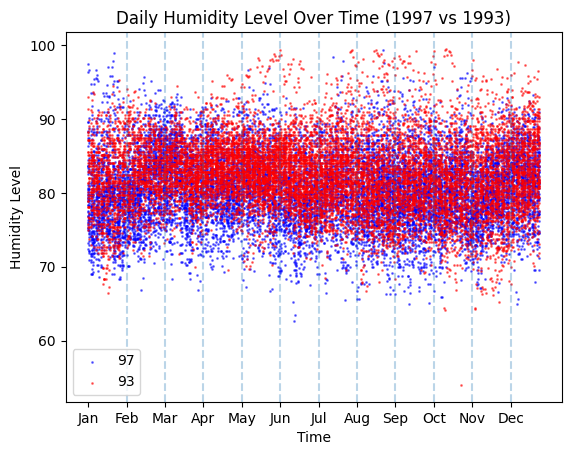

In [ ]:
humidity1 = humidity[(df_cleaned["year"] == year1)]
plt.scatter(humidity1["month_day"], humidity1["humidity"], label=str(year1), color="blue", s=1, alpha=0.5)

humidity2 = humidity[(df_cleaned["year"] == year2)]
plt.scatter(humidity2["month_day"], humidity2["humidity"], label=str(year2), color="red", s=1, alpha=0.5)

# draw separators between months
for m in range(1, 12):
    plt.axvline(m * 31, linestyle="--", alpha=0.3)

# label months at center of each block
month_centers = [(m * 31) for m in range(12)]
plt.xticks(
    month_centers,
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.title(f"Daily Humidity Level Over Time (19{year1} vs 19{year2})")
plt.xlabel('Time')
plt.ylabel('Humidity Level')
plt.legend()
plt.show()

In [ ]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import geodatasets

<Axes: >

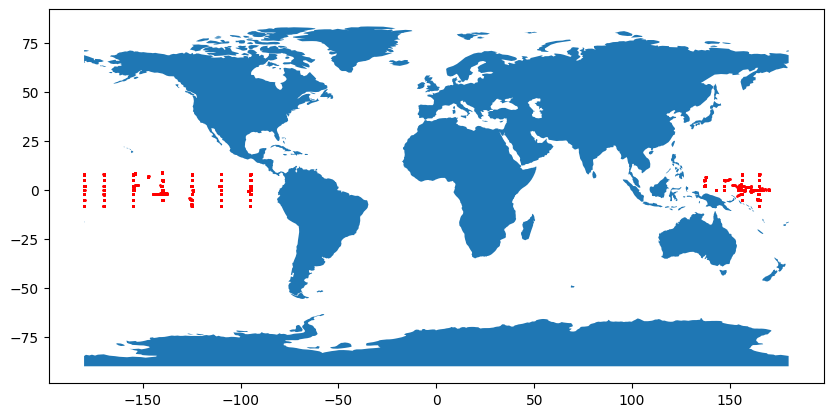

In [ ]:
locations = df_cleaned[["latitude", "longitude"]].drop_duplicates()

geometry = [Point(xy) for xy in zip(locations['longitude'], locations['latitude'])]
gdf = GeoDataFrame(locations, geometry=geometry) 

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
gdf.plot(ax=world.plot(figsize=(10, 6)), marker='o', color='red', markersize=1)



In [ ]:
import seaborn as sns
import matplotlib.dates as mdates

In [ ]:
df_cleaned = df_cleaned.sort_values(by='date')
west_hem = df_cleaned[(df_cleaned["longitude"] <= -50 )]
west_hem.drop(["longitude", "latitude"], axis=1, inplace=True)

west_hem_grouped = west_hem.groupby(["year", "month", "day", "date"]).mean()

west_hem_grouped.reset_index(inplace=True)

west_hem_grouped["date"] = pd.to_datetime(west_hem_grouped["date"].astype(str), format="%y%m%d")
west_hem_grouped.head(10)

,year,month,day,date,zon_winds,mer_winds,humidity,air_temp,ss_temp
0,89,11,29,1989-11-29,-7.20,-0.20,78.70,26.010,25.920
1,89,11,30,1989-11-30,-6.10,0.20,76.90,25.820,25.980
2,89,12,1,1989-12-01,-5.20,0.00,75.90,25.580,26.030
3,89,12,2,1989-12-02,-3.70,-0.40,76.80,25.460,26.140
4,89,12,3,1989-12-03,-4.60,-0.60,75.70,25.540,26.160
5,89,12,4,1989-12-04,-5.30,-3.00,74.35,26.580,27.075
6,89,12,5,1989-12-05,-6.35,-0.95,76.45,26.715,27.050
7,89,12,6,1989-12-06,-7.15,-1.40,77.20,26.895,26.985
8,89,12,7,1989-12-07,-6.60,-0.75,78.90,26.855,26.950
9,89,12,8,1989-12-08,-5.95,0.05,82.35,26.420,26.970


In [ ]:
import matplotlib.dates as mdates

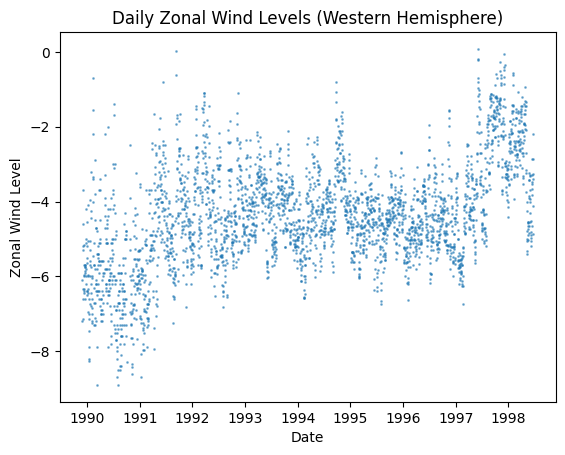

In [ ]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["zon_winds"], marker="o",alpha=0.5, s=1)
plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels (Western Hemisphere)")

plt.show()

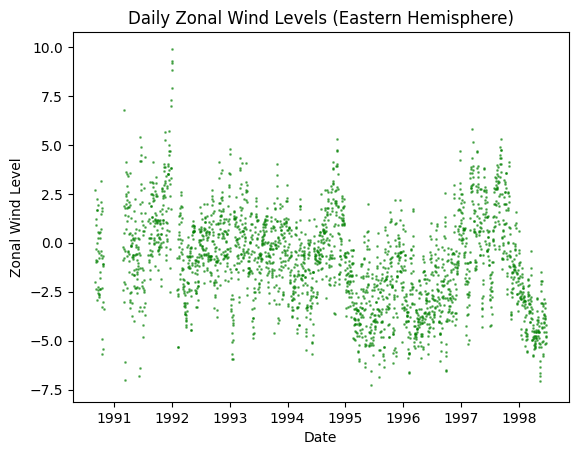

In [ ]:
east_hem = df_cleaned[(df_cleaned["longitude"] > -50 )]
east_hem.drop(["longitude", "latitude"], axis=1, inplace=True)

east_hem_grouped = east_hem.groupby(["year", "month", "day", "date"]).mean()

east_hem_grouped.reset_index(inplace=True)

east_hem_grouped["date"] = pd.to_datetime(east_hem_grouped["date"].astype(str), format="%y%m%d")

plt.scatter(east_hem_grouped["date"], east_hem_grouped["zon_winds"], marker="o",alpha=0.5, s=1, color="green")
plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels (Eastern Hemisphere)")

plt.show()

In [ ]:
# Point Settings
alpha = 1
size = 0.6


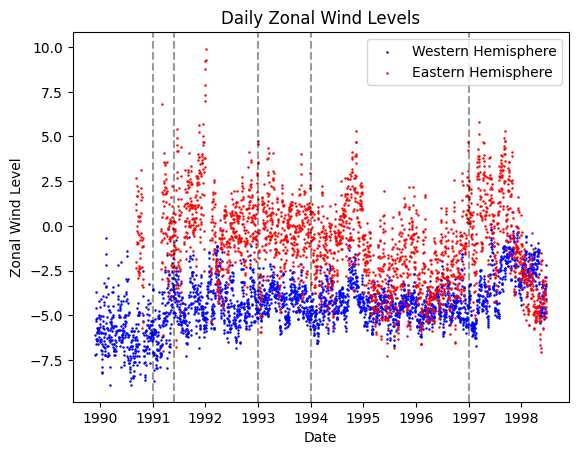

In [ ]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["zon_winds"], label="Western Hemisphere", marker="o",alpha=alpha, s=size, color="blue")
plt.scatter(east_hem_grouped["date"], east_hem_grouped["zon_winds"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=size, color="red")
plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels")
plt.legend()
plot_vertical_lines()

plt.show()


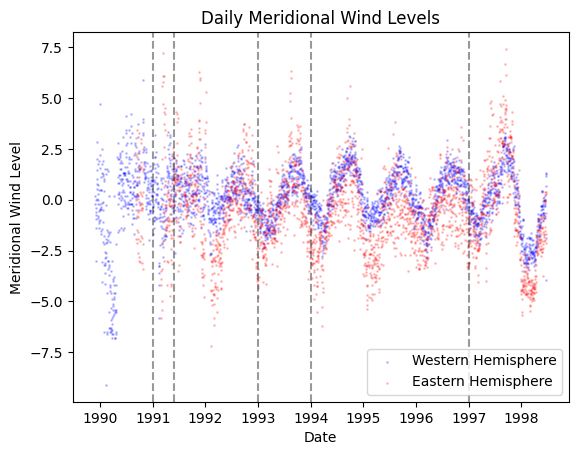

In [ ]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["mer_winds"], label="Western Hemisphere", marker="o",alpha=0.2, s=1, color="blue")
plt.scatter(east_hem_grouped["date"], east_hem_grouped["mer_winds"], label="Eastern Hemisphere", marker="o",alpha=0.2, s=1, color="red")
plt.xlabel("Date")
plt.ylabel("Meridional Wind Level")
plt.title("Daily Meridional Wind Levels")
plt.legend()

plot_vertical_lines()
plt.show()

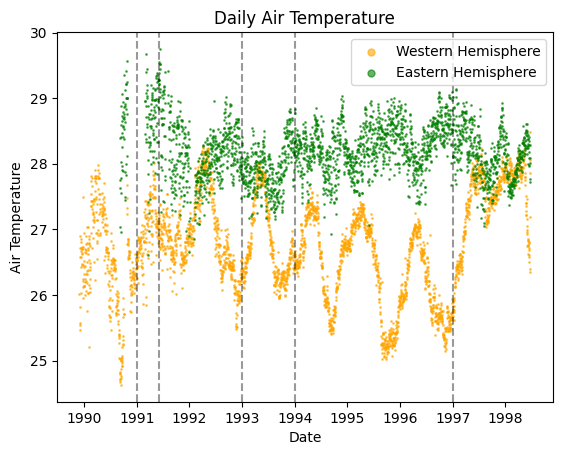

In [ ]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["air_temp"], label="Western Hemisphere", marker="o",alpha=0.6, s=1, color="orange")
plt.scatter(east_hem_grouped["date"], east_hem_grouped["air_temp"], label="Eastern Hemisphere", marker="o",alpha=0.6, s=1, color="green")
plt.xlabel("Date")
plt.ylabel("Air Temperature")
plt.title("Daily Air Temperature")
plt.legend(markerscale=5)
plot_vertical_lines()

plt.show()

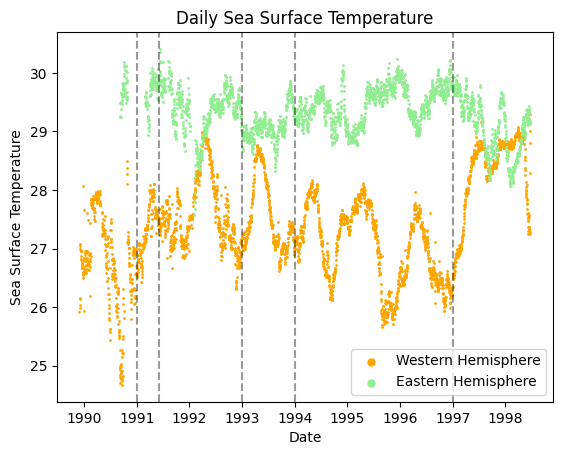

In [ ]:
plt.scatter(west_hem_grouped["date"], west_hem_grouped["ss_temp"], label="Western Hemisphere", marker="o",alpha=alpha, s=1, color="orange")
plt.scatter(east_hem_grouped["date"], east_hem_grouped["ss_temp"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=1, color="lightgreen")
plt.xlabel("Date")
plt.ylabel("Sea Surface Temperature")
plt.title("Daily Sea Surface Temperature")
plt.legend(markerscale=5)

plot_vertical_lines()

plt.show()

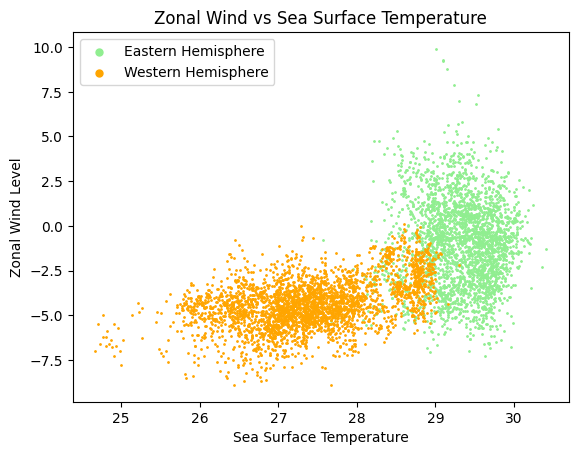

In [ ]:
plt.scatter(east_hem_grouped["ss_temp"], east_hem_grouped["zon_winds"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=1, color="lightgreen")
plt.scatter(west_hem_grouped["ss_temp"], west_hem_grouped["zon_winds"], label="Western Hemisphere", marker="o",alpha=alpha, s=1, color="orange")

plt.xlabel("Sea Surface Temperature")
plt.ylabel("Zonal Wind Level")
plt.title("Zonal Wind vs Sea Surface Temperature")
plt.legend(markerscale=5)
plt.show()

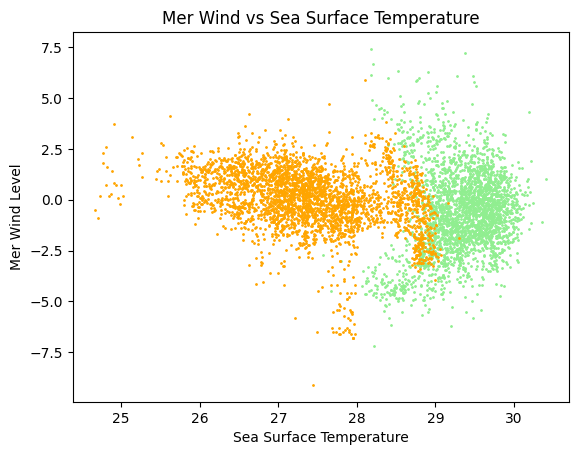

In [ ]:
plt.scatter(east_hem_grouped["ss_temp"], east_hem_grouped["mer_winds"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=1, color="lightgreen")
plt.scatter(west_hem_grouped["ss_temp"], west_hem_grouped["mer_winds"], label="Western Hemisphere",marker="o",alpha=alpha, s=1, color="orange")

plt.xlabel("Sea Surface Temperature")
plt.ylabel("Mer Wind Level")
plt.title("Mer Wind vs Sea Surface Temperature")
plt.show()

Text(0.5, 1.0, 'Correlation Plot of Weather Features')

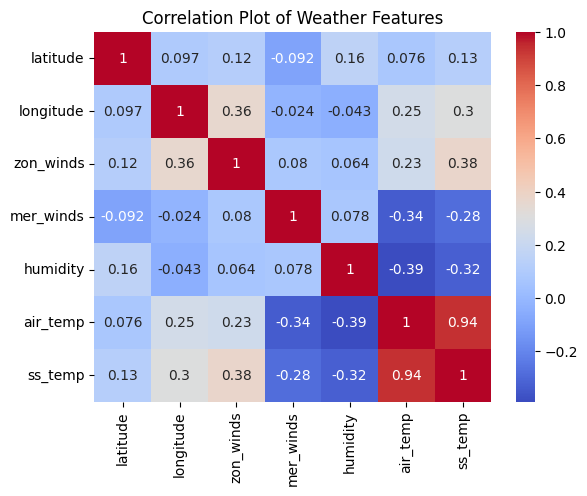

In [ ]:
weather_features = df_cleaned.drop(["year", "month", "day", "date"], axis=1)
corr = weather_features.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Plot of Weather Features")


Text(0.5, 1.0, 'Correlation Plot of Weather Features')

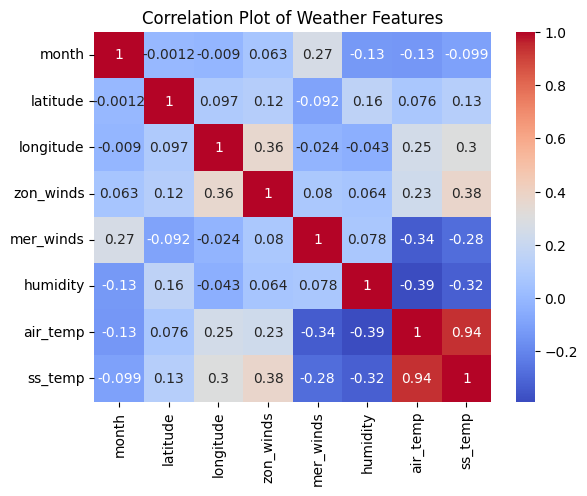

In [ ]:
weather_features = df_cleaned.drop(["year", "day", "date"], axis=1)
corr = weather_features.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Plot of Weather Features")

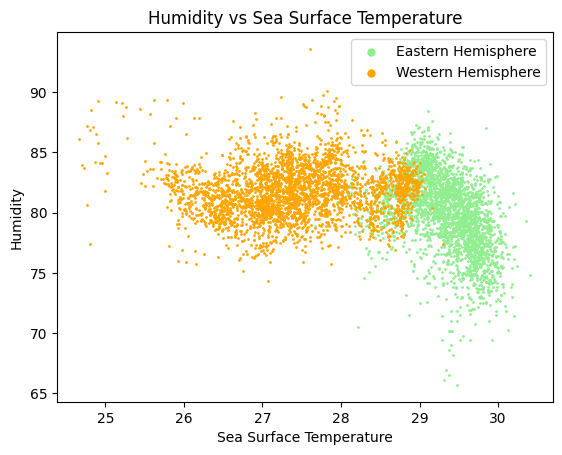

In [ ]:
plt.scatter(east_hem_grouped["ss_temp"], east_hem_grouped["humidity"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=1, color="lightgreen")
plt.scatter(west_hem_grouped["ss_temp"], west_hem_grouped["humidity"], label="Western Hemisphere", marker="o",alpha=alpha, s=1, color="orange")

plt.xlabel("Sea Surface Temperature")
plt.ylabel("Humidity")
plt.title("Humidity vs Sea Surface Temperature")
plt.legend(markerscale=5)
plt.show()

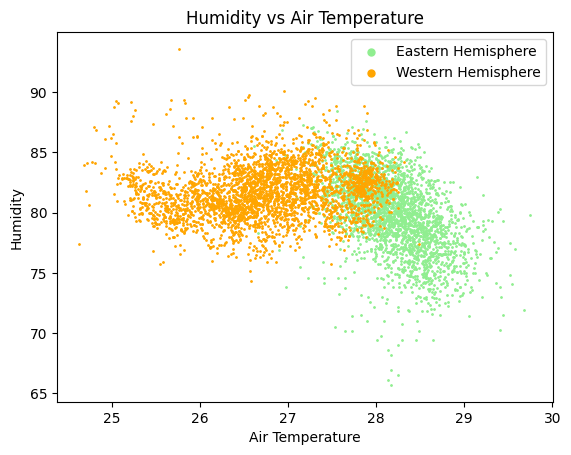

In [ ]:
plt.scatter(east_hem_grouped["air_temp"], east_hem_grouped["humidity"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=1, color="lightgreen")
plt.scatter(west_hem_grouped["air_temp"], west_hem_grouped["humidity"], label="Western Hemisphere", marker="o",alpha=alpha, s=1, color="orange")

plt.xlabel("Air Temperature")
plt.ylabel("Humidity")
plt.title("Humidity vs Air Temperature")
plt.legend(markerscale=5)
plt.show()

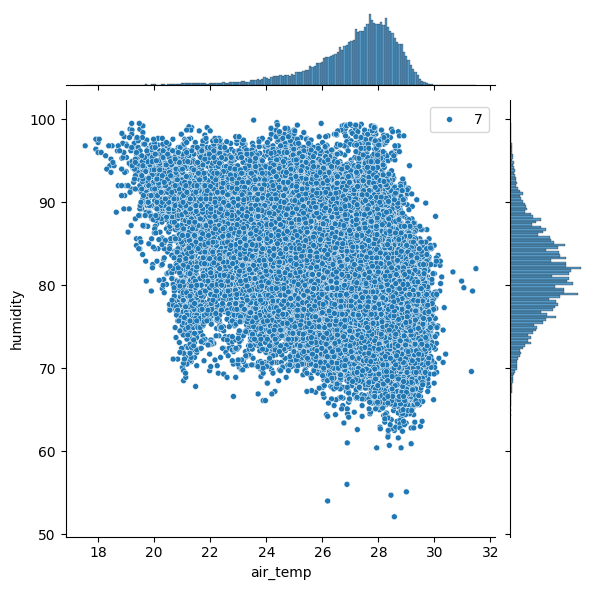

In [ ]:
sns.jointplot(x="air_temp", y="humidity", data=df_cleaned, size=7)

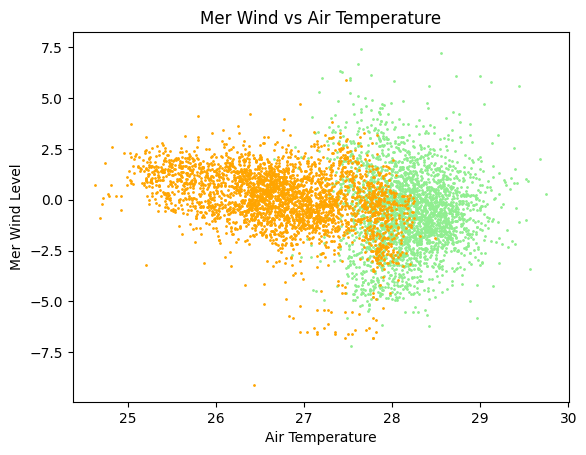

In [ ]:
plt.scatter(east_hem_grouped["air_temp"], east_hem_grouped["mer_winds"], label="Eastern Hemisphere", marker="o",alpha=alpha, s=1, color="lightgreen")
plt.scatter(west_hem_grouped["air_temp"], west_hem_grouped["mer_winds"], label="Western Hemisphere",marker="o",alpha=alpha, s=1, color="orange")

plt.xlabel("Air Temperature")
plt.ylabel("Mer Wind Level")
plt.title("Mer Wind vs Air Temperature")
plt.show()